<a href="https://colab.research.google.com/github/hridibazaman03/220142_KNN/blob/main/220142_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

from matplotlib.colors import ListedColormap

In [57]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

In [58]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [59]:
print(df.shape)

(891, 12)


In [60]:
num_cols = df.select_dtypes(include=np.number).columns

In [61]:
num_imputer = SimpleImputer(strategy='mean')

In [62]:
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [63]:
cat_cols = df.select_dtypes(include='object').columns

In [64]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [65]:
le = LabelEncoder()

In [66]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [67]:
X = df.drop('Survived', axis=1)

In [68]:
y = df['Survived']

In [69]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [70]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [71]:
scaler = StandardScaler()

In [72]:
X_train = scaler.fit_transform(X_train)

In [73]:
X_val = scaler.transform(X_val)

In [74]:
X_test = scaler.transform(X_test)

In [75]:
error_rate = []

In [76]:
for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

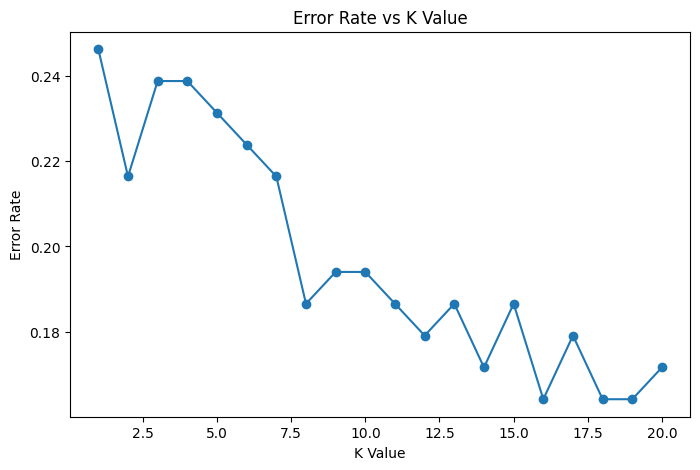

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    error_rate,
    marker='o'
)

plt.title("Error Rate vs K Value")

plt.xlabel("K Value")

plt.ylabel("Error Rate")

plt.show()

In [78]:
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [79]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [80]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [81]:
print(grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [82]:
best_knn = grid.best_estimator_

In [83]:
y_pred = best_knn.predict(X_test)

In [84]:
y_prob = best_knn.predict_proba(X_test)[:,1]

In [85]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7835820895522388


In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7142857142857143


In [86]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6382978723404256


In [87]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6741573033707865


In [88]:
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.7979946197114209


In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        87
         1.0       0.71      0.64      0.67        47

    accuracy                           0.78       134
   macro avg       0.76      0.75      0.76       134
weighted avg       0.78      0.78      0.78       134



In [90]:
cm = confusion_matrix(y_test, y_pred)

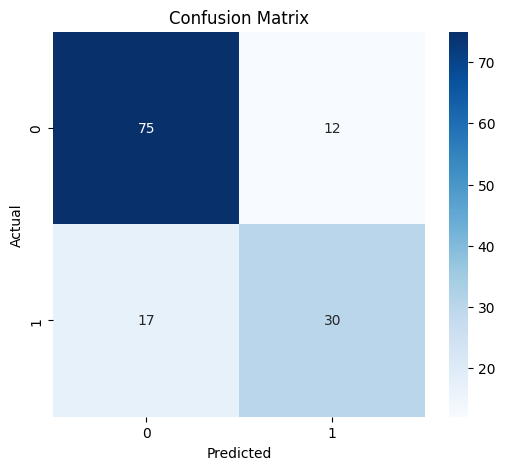

In [91]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

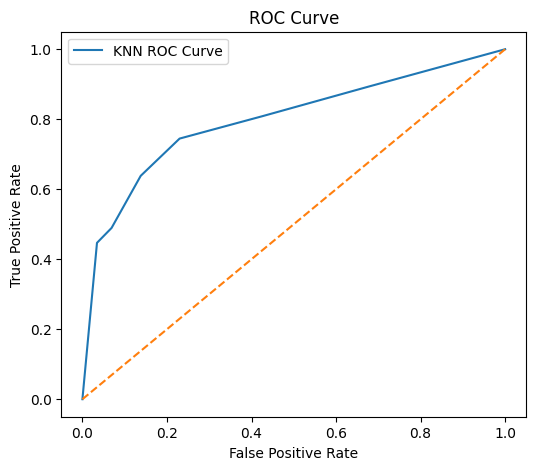

In [93]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='KNN ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print(results.head(10))


   Actual  Predicted  Probability
0     0.0        0.0     0.000000
1     0.0        0.0     0.000000
2     1.0        0.0     0.428571
3     0.0        0.0     0.000000
4     0.0        0.0     0.428571
5     0.0        1.0     0.571429
6     0.0        0.0     0.142857
7     0.0        0.0     0.142857
8     0.0        0.0     0.000000
9     0.0        0.0     0.000000


In [94]:
X2 = X.iloc[:, :2]

In [95]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.30,
    random_state=42
)

In [98]:
scaler2 = StandardScaler()

In [99]:
X2_train = scaler2.fit_transform(X2_train)

In [100]:
X2_test = scaler2.transform(X2_test)

In [101]:
knn2 = KNeighborsClassifier(n_neighbors=5)

In [102]:
knn2.fit(X2_train, y2_train)

KNeighborsClassifier()

In [103]:
x1, x2 = np.meshgrid(
    np.arange(
        X2_train[:,0].min()-1,
        X2_train[:,0].max()+1,
        0.01
    ),
    np.arange(
        X2_train[:,1].min()-1,
        X2_train[:,1].max()+1,
        0.01
    )
)

In [104]:
Z = knn2.predict(
    np.array([x1.ravel(), x2.ravel()]).T
)

In [105]:
Z = Z.reshape(x1.shape)

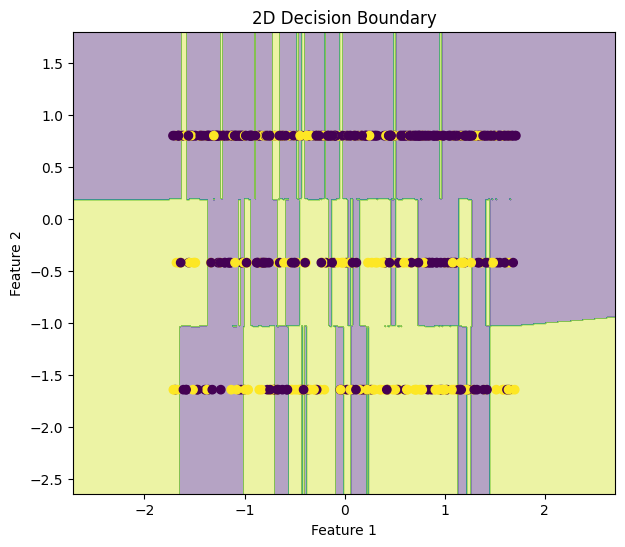

In [106]:
plt.figure(figsize=(7,6))

plt.contourf(x1, x2, Z, alpha=0.4)

plt.scatter(
    X2_train[:,0],
    X2_train[:,1],
    c=y2_train
)

plt.title("2D Decision Boundary")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()